In [10]:
import time
import pandas as pd
import json
import numpy as np
from datetime import datetime
from datetime import timezone
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from matplotlib.colors import ListedColormap
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import plotly.graph_objects as go
from plotly.subplots import make_subplots


import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [11]:
from scipy.interpolate import interp1d
# resample target
def resample_cycle(cycle, num_points):
	"""Resamples a gait cycle to have a fixed number of points using interpolation."""
	original_indices = np.linspace(0, 1, len(cycle))  # original indices based on the length of the cycle
	new_indices = np.linspace(0, 1, num_points)  # new indices to match the desired number of points
	interpolation_function = interp1d(original_indices, cycle, kind='linear')  # interpolate the data
	return interpolation_function(new_indices)  # return the resampled cycle

In [12]:
def read_json_from_ros2bag(json_file, print_ = False):
	list_of_length = []
	with open(json_file, 'r') as file:
		json_content = json.load(file)
	if print_:
		print('Read: ',json_file)
	for key, value in json_content.items():
		if print_:
			print(f"{key} range: {len(value)}")
		list_of_length.append(len(value))
	cut_data = {key: value[:min(list_of_length)] for key, value in json_content.items()}
	cut_df = pd.DataFrame(cut_data)
	return cut_df


def read_and_normalize_json_from_ros2bag(json_file, print_=False):
	list_of_length = []
	with open(json_file, 'r') as f:
		data = json.load(f)
	if print_:
		print('Read: ',json_file)
	for key, value in data.items():
		if print_:
			print(f"{key} range: {len(value)}")
		list_of_length.append(len(value))
	# Normalize the data into a DataFrame
	df = pd.json_normalize(data)
	return df

def remove_specific_cycles(data_loader, indices_to_remove):
	"""
	Excludes specific indices from every key in the dataset.
	indices_to_remove: list of integers (e.g., [1, 3, 6])
	"""
	cleaned_data = {}
	
	for key in data_loader.files:
		original_list = list(data_loader[key])
		# Keep only the items whose index is NOT in our 'remove' list
		cleaned_data[key] = [
			cycle for i, cycle in enumerate(original_list) 
			if i not in indices_to_remove
		]
		
	return cleaned_data

def get_cycle_stats(data_source, param_prefix, leg, norm_points=100):
	"""
	Interpolates cycles for a specific leg/parameter and calculates mean/std.
	"""
	key = f'{param_prefix}_{leg}'
	if key not in data_source:
		return None, None, None

	raw_cycles = data_source[key]
	normalized_list = []
	

	for j, cycle in enumerate(raw_cycles):
			
		x_old = np.linspace(0, 100, len(cycle))
		x_new = np.linspace(0, 100, norm_points)
		norm_cycle = np.interp(x_new, x_old, cycle)
		normalized_list.append(norm_cycle)
	
	if not normalized_list:
		return None, None, None

	norm_matrix = np.array(normalized_list)
	mean_vals = np.mean(norm_matrix, axis=0)
	std_vals = np.std(norm_matrix, axis=0)
	x_axis = np.linspace(0, 100, norm_points)

	return x_axis, mean_vals, std_vals

def process_sensor_data(input_df, sensor_key, output_column, window_slide=1, shift=0):
	sensor_val = []
	sensor_ts = []
	sensor_df = []

	for i in range(len(input_df[sensor_key][0])):
		sensor_val.append(input_df[sensor_key][0][i]['val'])
		sensor_ts.append(input_df[sensor_key][0][i]['ts'])

	sensor_df = pd.DataFrame(sensor_val, columns=output_column)
	sensor_df = sensor_df.shift(shift)
	sensor_df = sensor_df.rolling(window=window_slide).mean()
	sensor_df['ts'] = sensor_ts

	return sensor_df

Found 36 CSV file(s). Processing...

--- Processed Data Summary ---
                Gait     Environment  Cost_of_Transport
   Muddy Ground Gait    Muddy Ground           0.000015
   Muddy Ground Gait    Rough Ground           0.135602
   Muddy Ground Gait Slippery Ground           2.034125
   Muddy Ground Gait     Soft Ground           5.612011
   Muddy Ground Gait    Solid Ground          10.686654
   Muddy Ground Gait   Water Surface           0.005562
   Rough Ground Gait    Muddy Ground           3.526493
   Rough Ground Gait    Rough Ground           0.010132
   Rough Ground Gait Slippery Ground           3.486812
   Rough Ground Gait     Soft Ground           0.000310
   Rough Ground Gait    Solid Ground          14.112073
   Rough Ground Gait   Water Surface           8.686678
Slippery Ground Gait    Muddy Ground           3.160438
Slippery Ground Gait    Rough Ground           0.069206
Slippery Ground Gait Slippery Ground           0.000021
Slippery Ground Gait     Soft Ground

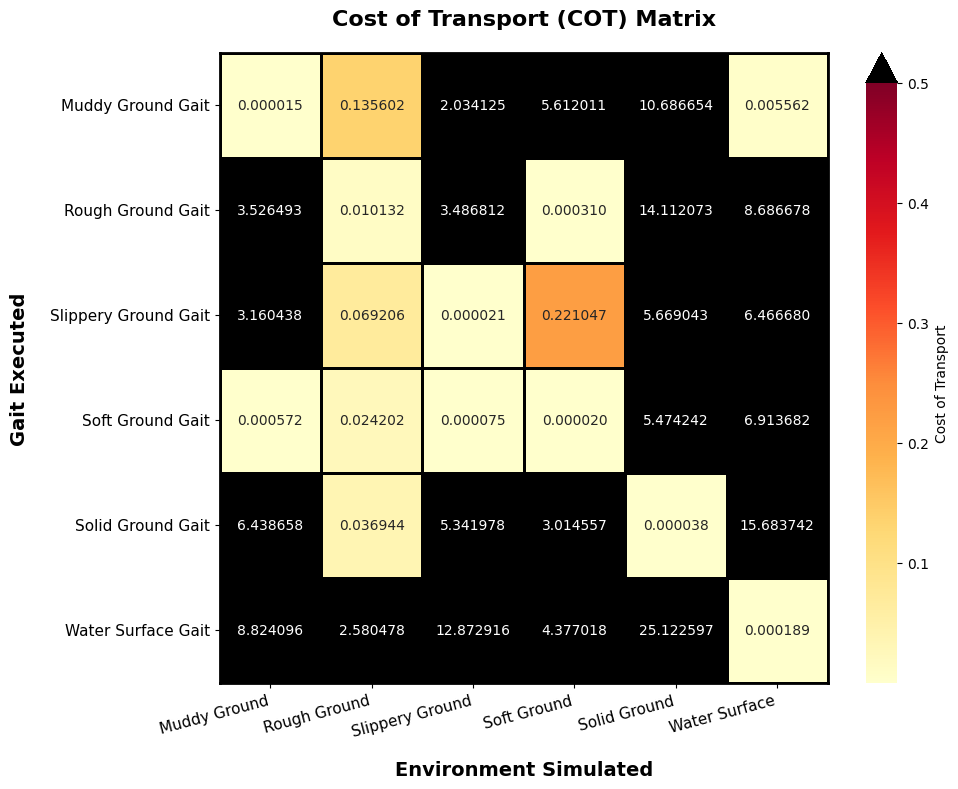

In [17]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import copy # <-- NEW: Needed to modify the colormap safely

# ==========================================
# CONFIGURATION
# ==========================================
CSV_FOLDER = "" 

def load_and_average_csvs(folder_path):
    """Finds CSV files, extracts Gait/Env from filename, and calculates averages."""
    search_pattern = os.path.join(folder_path, "*.csv")
    csv_files = glob.glob(search_pattern)
    
    if not csv_files:
        print(f"No CSV files found in {folder_path}!")
        return None

    print(f"Found {len(csv_files)} CSV file(s). Processing...")
    
    avg_data = []
    
    for file in sorted(csv_files):
        df = pd.read_csv(file)
        
        # Calculate the average of all numeric columns in this file
        numeric_cols = df.select_dtypes(include='number').columns
        avg_row = df[numeric_cols].mean().to_dict()
        
        # 🚨 PARSE THE FILENAME 🚨
        # Filename expected format: "gait_name_on_environment_name.csv"
        filename_clean = os.path.splitext(os.path.basename(file))[0]
        
        if "_on_" in filename_clean:
            # Split the string at "_on_"
            gait_name, env_name = filename_clean.split('_on_', 1)
        else:
            # Fallback if a file doesn't follow the naming convention
            gait_name = filename_clean
            env_name = "Unknown_Environment"
            
        avg_row['Gait'] = gait_name.replace('_', ' ').title()
        avg_row['Environment'] = env_name.replace('_', ' ').title()
        avg_row['Episodes_Count'] = len(df)
        
        avg_data.append(avg_row)
        
    return pd.DataFrame(avg_data)

def plot_cot_heatmap(df):
    """Generates a 2D grid (heatmap) for Cost of Transport: Gait vs Environment."""
    
    # 1. Pivot the data into a 2D Matrix (Rows = Gait, Columns = Environment)
    pivot_df = df.pivot_table(
        index='Gait', 
        columns='Environment', 
        values='Cost_of_Transport', 
        aggfunc='mean'
    )
    
    # 2. Set up the plot window
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # ==========================================
    # 🚨 NEW: CUSTOM COLORMAP LOGIC
    # ==========================================
    # Get the base Yellow-Orange-Red colormap
    my_cmap = copy.copy(plt.get_cmap("YlOrRd"))
    # Tell it to color anything above the maximum threshold as solid black
    my_cmap.set_over('black')
    
    # 3. Draw the Heatmap
    sns.heatmap(
        pivot_df, 
        annot=True,          
        fmt=".6f",           # Changed to 4 decimals so it fits nicely in the black squares
        cmap=my_cmap,        # Use our custom colormap
        vmax=0.5,            # 🚨 Force the standard color scale to STOP exactly at 1.0!
        linewidths=1,        
        linecolor='black',
        cbar_kws={
            'label': 'Cost of Transport', 
            'extend': 'max'  # 🚨 Adds an arrow to the colorbar indicating >1.0 goes black
        },
        ax=ax
    )
    
    for _, spine in ax.spines.items():
        spine.set_visible(True)     # Make sure the frame is turned on
        spine.set_linewidth(2.0)    # Set the outer frame thickness to 3
        spine.set_color('black')    # Set the outer frame color

    # 4. Formatting labels and titles
    ax.set_title("Cost of Transport (COT) Matrix", 
                 fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel("Environment Simulated", fontsize=14, fontweight='bold', labelpad=15)
    ax.set_ylabel("Gait Executed", fontsize=14, fontweight='bold', labelpad=15)
    
    # Rotate the X-axis labels slightly if the environment names are long
    plt.xticks(rotation=15, ha='right', fontsize=11)
    plt.yticks(rotation=0, fontsize=11)
    
    # Automatically adjust spacing
    plt.tight_layout() 
    
    # Save the plot
    save_path = "gait_vs_environment_COT_grid.png"
    plt.savefig(save_path, dpi=300)
    print(f"Plot saved successfully to: {save_path}")
    
    # Show the plot
    plt.show()

if __name__ == "__main__":
    # 1. Load Data
    df = load_and_average_csvs(CSV_FOLDER)
    
    if df is not None and not df.empty:
        print("\n--- Processed Data Summary ---")
        print(df[['Gait', 'Environment', 'Cost_of_Transport']].to_string(index=False))
        
        # 2. Plot the Heatmap Grid
        plot_cot_heatmap(df)

Found 36 CSV file(s). Processing...

--- Processed Data Summary ---
                Gait     Environment  Stability_Index
   Muddy Ground Gait    Muddy Ground         0.005927
   Muddy Ground Gait    Rough Ground         0.114254
   Muddy Ground Gait Slippery Ground         0.830760
   Muddy Ground Gait     Soft Ground         0.583463
   Muddy Ground Gait    Solid Ground         0.770010
   Muddy Ground Gait   Water Surface         0.133858
   Rough Ground Gait    Muddy Ground         0.817203
   Rough Ground Gait    Rough Ground         0.282059
   Rough Ground Gait Slippery Ground         0.843943
   Rough Ground Gait     Soft Ground         0.502311
   Rough Ground Gait    Solid Ground         0.724922
   Rough Ground Gait   Water Surface         0.365196
Slippery Ground Gait    Muddy Ground         0.272603
Slippery Ground Gait    Rough Ground         0.863930
Slippery Ground Gait Slippery Ground         0.052322
Slippery Ground Gait     Soft Ground         0.652165
Slippery Groun

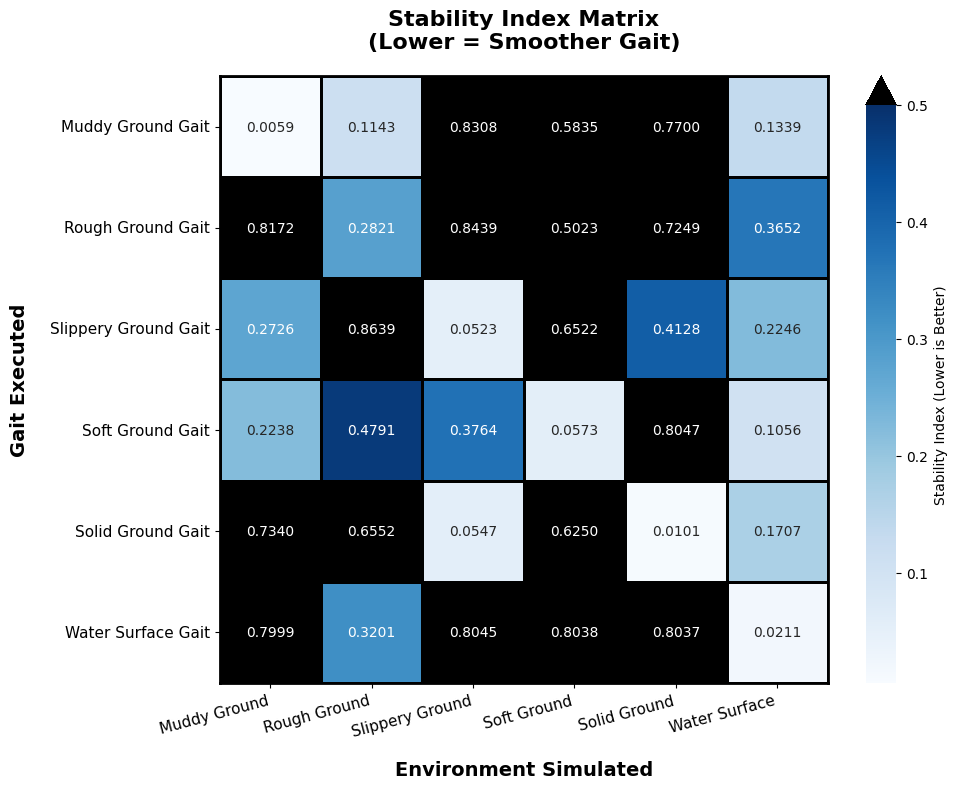

In [15]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import copy

# ==========================================
# CONFIGURATION
# ==========================================
CSV_FOLDER = "" # <-- Put your folder path here, e.g., "terrain_dataset/metric/"

def load_and_average_csvs(folder_path):
    """Finds CSV files, extracts Gait/Env from filename, and calculates averages."""
    search_pattern = os.path.join(folder_path, "*.csv")
    csv_files = glob.glob(search_pattern)
    
    if not csv_files:
        print(f"No CSV files found in {folder_path}!")
        return None

    print(f"Found {len(csv_files)} CSV file(s). Processing...")
    
    avg_data = []
    
    for file in sorted(csv_files):
        df = pd.read_csv(file)
        
        # Calculate the average of all numeric columns in this file
        numeric_cols = df.select_dtypes(include='number').columns
        avg_row = df[numeric_cols].mean().to_dict()
        
        # 🚨 PARSE THE FILENAME 🚨
        # Filename expected format: "gait_name_on_environment_name.csv"
        filename_clean = os.path.splitext(os.path.basename(file))[0]
        
        if "_on_" in filename_clean:
            # Split the string at "_on_"
            gait_name, env_name = filename_clean.split('_on_', 1)
        else:
            # Fallback if a file doesn't follow the naming convention
            gait_name = filename_clean
            env_name = "Unknown_Environment"
            
        avg_row['Gait'] = gait_name.replace('_', ' ').title()
        avg_row['Environment'] = env_name.replace('_', ' ').title()
        avg_row['Episodes_Count'] = len(df)
        
        avg_data.append(avg_row)
        
    return pd.DataFrame(avg_data)

def plot_instability_heatmap(df):
    """Generates a 2D grid (heatmap) for Instability: Gait vs Environment."""
    
    # 1. Pivot the data into a 2D Matrix (Rows = Gait, Columns = Environment)
    pivot_df = df.pivot_table(
        index='Gait', 
        columns='Environment', 
        values='Stability_Index',  # 🚨 CHANGED: Now pulls the Instability metric
        aggfunc='mean'
    )
    
    # 2. Set up the plot window
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # ==========================================
    # 🚨 CUSTOM COLORMAP LOGIC
    # ==========================================
    # Get the base Yellow-Orange-Red colormap
    my_cmap = copy.copy(plt.get_cmap("Blues"))
    # Tell it to color anything above the maximum threshold as solid black
    my_cmap.set_over('black')
    
    # 3. Draw the Heatmap
    sns.heatmap(
        pivot_df, 
        annot=True,          
        fmt=".4f",           # 4 decimals looks clean in the boxes
        cmap=my_cmap,        
        vmax=0.5,            # 🚨 CHANGE THIS: Set this to your desired threshold for "Failure/Black"
        linewidths=1,        
        linecolor='black',
        cbar_kws={
            'label': 'Stability Index (Lower is Better)', # 🚨 CHANGED: Label updated
            'extend': 'max'  
        },
        ax=ax
    )
    
    for _, spine in ax.spines.items():
        spine.set_visible(True)     # Make sure the frame is turned on
        spine.set_linewidth(2.0)    # Set the outer frame thickness
        spine.set_color('black')    # Set the outer frame color

    # 4. Formatting labels and titles
    ax.set_title("Stability Index Matrix\n(Lower = Smoother Gait)", # 🚨 CHANGED: Title updated
                 fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel("Environment Simulated", fontsize=14, fontweight='bold', labelpad=15)
    ax.set_ylabel("Gait Executed", fontsize=14, fontweight='bold', labelpad=15)
    
    # Rotate the X-axis labels slightly if the environment names are long
    plt.xticks(rotation=15, ha='right', fontsize=11)
    plt.yticks(rotation=0, fontsize=11)
    
    # Automatically adjust spacing
    plt.tight_layout() 
    
    # Save the plot
    save_path = "gait_vs_environment_Instability_grid.png" # 🚨 CHANGED: Save file name updated
    plt.savefig(save_path, dpi=300)
    print(f"Plot saved successfully to: {save_path}")
    
    # Show the plot
    plt.show()

if __name__ == "__main__":
    # 1. Load Data
    df = load_and_average_csvs(CSV_FOLDER)
    
    if df is not None and not df.empty:
        print("\n--- Processed Data Summary ---")
        # 🚨 CHANGED: Print summary now shows Stability Index instead of COT
        print(df[['Gait', 'Environment', 'Stability_Index']].to_string(index=False))
        
        # 2. Plot the Heatmap Grid
        plot_instability_heatmap(df)